# Análise Completa de Trajetórias de Clusters por Usuário

Pipeline completo:
1. Leitura do CSV `user_topic_cluster_labels_umap_order1.csv`
2. Matriz usuário×assignment (a1..a7)
3. Sankey agregado (colunas fixas por tópico, clusters ordenados)
4. Distância Hamming mascarada
5. Seleção de K por **Silhouette**
6. Agglomerative Clustering + dendrograma
7. Heatmap com grupos no eixo Y e separadores
8. UMAP (one-hot) colorido por grupo


In [4]:
# =======================
# 0) Configurações
# =======================
from pathlib import Path
CSV_PATH = Path("./da_artifacts/user_topic_cluster_labels_umap_order1.csv")
TOPIC_ORDER = [f"a{i}" for i in range(1, 8)]  # a1..a7
LINKAGE = "average"
RANDOM_STATE = 42
OUT_DIR = Path("./trajetory")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
# =======================
# 1) Imports e helpers
# =======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from collections import Counter
import warnings

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

def warn_file_absent(path: Path):
    if not path.exists():
        print(f"⚠️ Arquivo não encontrado: {path.resolve()} — usando dataset de exemplo.")
        return True
    return False


/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# =======================
# 2) Leitura do CSV e preparação
# =======================
if warn_file_absent(CSV_PATH):
    df = pd.DataFrame({
        "userId": ["u1","u1","u1","u2","u2","u2","u3","u3","u3"],
        "topic":  ["a1","a2","a3","a1","a2","a3","a1","a2","a3"],
        "cluster":[0,1,2,0,0,1,3,3,2],
    })
else:
    df = pd.read_csv(CSV_PATH)

df.columns = [c.strip() for c in df.columns]
df["topic"] = df["topic"].astype(str).str.strip().str.lower()
df = df[df["topic"].isin(TOPIC_ORDER)].copy()
df["topic"] = pd.Categorical(df["topic"], categories=TOPIC_ORDER, ordered=True)
df = df.sort_values(["userId", "topic"]).reset_index(drop=True)

display(df.head(10))
print(f"N usuários = {df['userId'].nunique()}, N registros = {len(df)}")


,userId,topic,cluster
0,011bb520-7041-704f-b3e7-ab5c43dd3950,a1,2
1,011bb520-7041-704f-b3e7-ab5c43dd3950,a2,4
2,011bb520-7041-704f-b3e7-ab5c43dd3950,a4,2
3,011bb520-7041-704f-b3e7-ab5c43dd3950,a5,6
4,011bb520-7041-704f-b3e7-ab5c43dd3950,a6,8
5,011bb520-7041-704f-b3e7-ab5c43dd3950,a7,2
6,011bd560-70e1-7036-62a9-3d29afd5179d,a2,0
7,011bd560-70e1-7036-62a9-3d29afd5179d,a3,0
8,011bd560-70e1-7036-62a9-3d29afd5179d,a4,6
9,011bd560-70e1-7036-62a9-3d29afd5179d,a5,8


N usuários = 201, N registros = 916


In [7]:
# =======================
# 3) Matriz usuário x tópico (trajetória)
# =======================
traj = df.pivot_table(index="userId", columns="topic", values="cluster", aggfunc="first")
traj = traj.reindex(columns=TOPIC_ORDER)
display(traj.head())

(traj).to_csv(OUT_DIR / "user_trajectory_matrix.csv")
print("Matriz salva em:", (OUT_DIR / "user_trajectory_matrix.csv").resolve())


/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38357/1625236966.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  traj = df.pivot_table(index="userId", columns="topic", values="cluster", aggfunc="first")


topic,a1,a2,a3,a4,a5,a6,a7
userId,,,,,,,
011bb520-7041-704f-b3e7-ab5c43dd3950,2.0,4.0,NaN,2.0,6.0,8.0,2.0
011bd560-70e1-7036-62a9-3d29afd5179d,NaN,0.0,0.0,6.0,8.0,2.0,NaN
012b8580-9011-70e5-0aa0-480c3bb39caa,NaN,7.0,2.0,NaN,2.0,NaN,2.0
014b6540-3041-705c-365b-d2029fb91b21,NaN,3.0,2.0,6.0,3.0,5.0,1.0
016b15c0-a071-70a4-d6d6-0aae841b512a,NaN,NaN,3.0,NaN,NaN,7.0,9.0


Matriz salva em: /Users/otacilio.maia/Desktop/studies/experimentosmestrado/helloworld/per_topic/trajetory/user_trajectory_matrix.csv


## 4) Sankey agregado de transições (colunas fixas e clusters ordenados)

In [8]:
# =======================
# 4) Sankey agregado de transições (colunas fixas e clusters ordenados)
# =======================
from collections import Counter
import numpy as np
import pandas as pd

topic_index = {t:i for i,t in enumerate(TOPIC_ORDER)}

edge_counts = Counter()
for uid, row in traj.iterrows():
    seq = row.values.tolist()
    for i in range(len(TOPIC_ORDER)-1):
        c_from, c_to = seq[i], seq[i+1]
        if pd.notna(c_from) and pd.notna(c_to):
            t_from = TOPIC_ORDER[i]
            t_to   = TOPIC_ORDER[i+1]
            edge_counts[(t_from, int(c_from), t_to, int(c_to))] += 1

if not edge_counts:
    print("Sem transições válidas para construir Sankey.")
else:
    clusters_by_topic = {t:set() for t in TOPIC_ORDER}
    for (t_from, c_from, t_to, c_to), v in edge_counts.items():
        clusters_by_topic[t_from].add(c_from)
        clusters_by_topic[t_to].add(c_to)

    nodes = {}
    labels = []
    node_x, node_y = [], []

    for t in TOPIC_ORDER:
        clusts = sorted(clusters_by_topic[t])
        m = max(len(clusts), 1)
        ys = np.linspace(0.9, 0.1, m)  # invertido: c0 no topo
        x_pos = 0.0 if len(TOPIC_ORDER)==1 else topic_index[t] / (len(TOPIC_ORDER)-1)
        for i_c, c in enumerate(clusts):
            nodes[(t,c)] = len(nodes)
            labels.append(f"{t}:c{c}")
            node_x.append(x_pos)
            node_y.append(ys[i_c])

    sources, targets, values = [], [], []
    for (t_from, c_from, t_to, c_to), v in edge_counts.items():
        s = nodes[(t_from, c_from)]
        t = nodes[(t_to, c_to)]
        sources.append(s)
        targets.append(t)
        values.append(int(v))

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(label=labels, pad=15, thickness=20, x=node_x, y=node_y),
        link=dict(source=sources, target=targets, value=values,
                  hovertemplate="de %{source.label} → %{target.label}<br>contagem: %{value}<extra></extra>")
    )])
    fig.update_layout(title_text="Transições de Clusters por Assignment (Sankey agregado — colunas fixas, clusters ordenados)")
    fig.show()


## 5) Tabelas de transição agregadas por etapa

In [9]:
# =======================
# 5) Tabelas de transição agregadas por passo
# =======================
all_transitions = []
for i in range(len(TOPIC_ORDER)-1):
    t_from, t_to = TOPIC_ORDER[i], TOPIC_ORDER[i+1]
    step_df = df[df["topic"].isin([t_from, t_to])].copy()
    step_wide = step_df.pivot_table(index="userId", columns="topic", values="cluster", aggfunc="first")
    step_wide = step_wide[[t_from, t_to]].dropna()
    if len(step_wide) == 0:
        continue
    ct = (step_wide.value_counts().rename("count").reset_index())
    ct["from_topic"] = t_from
    ct["to_topic"] = t_to
    ct = ct.rename(columns={t_from:"from_cluster", t_to:"to_cluster"})
    all_transitions.append(ct)

if all_transitions:
    trans_df = pd.concat(all_transitions, ignore_index=True)
    display(trans_df.head(20))
    trans_path = OUT_DIR / "transition_counts_by_step.csv"
    trans_df.to_csv(trans_path, index=False)
    print("Transições salvas em:", trans_path.resolve())
else:
    print("Sem transições agregadas para reportar.")


/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38357/2301501399.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38357/2301501399.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38357/2301501399.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38357/2301501399.py:8: FutureWarning:

The default value of obser

,from_cluster,to_cluster,count,from_topic,to_topic
0,8.0,0.0,4,a1,a2
1,5.0,5.0,4,a1,a2
2,8.0,6.0,3,a1,a2
3,0.0,0.0,2,a1,a2
4,2.0,3.0,2,a1,a2
5,6.0,4.0,2,a1,a2
6,8.0,2.0,2,a1,a2
7,3.0,4.0,2,a1,a2
8,8.0,5.0,2,a1,a2
9,8.0,4.0,1,a1,a2


Transições salvas em: /Users/otacilio.maia/Desktop/studies/experimentosmestrado/helloworld/per_topic/trajetory/transition_counts_by_step.csv


## 6) Distância Hamming mascarada, seleção de K por Silhouette e clustering

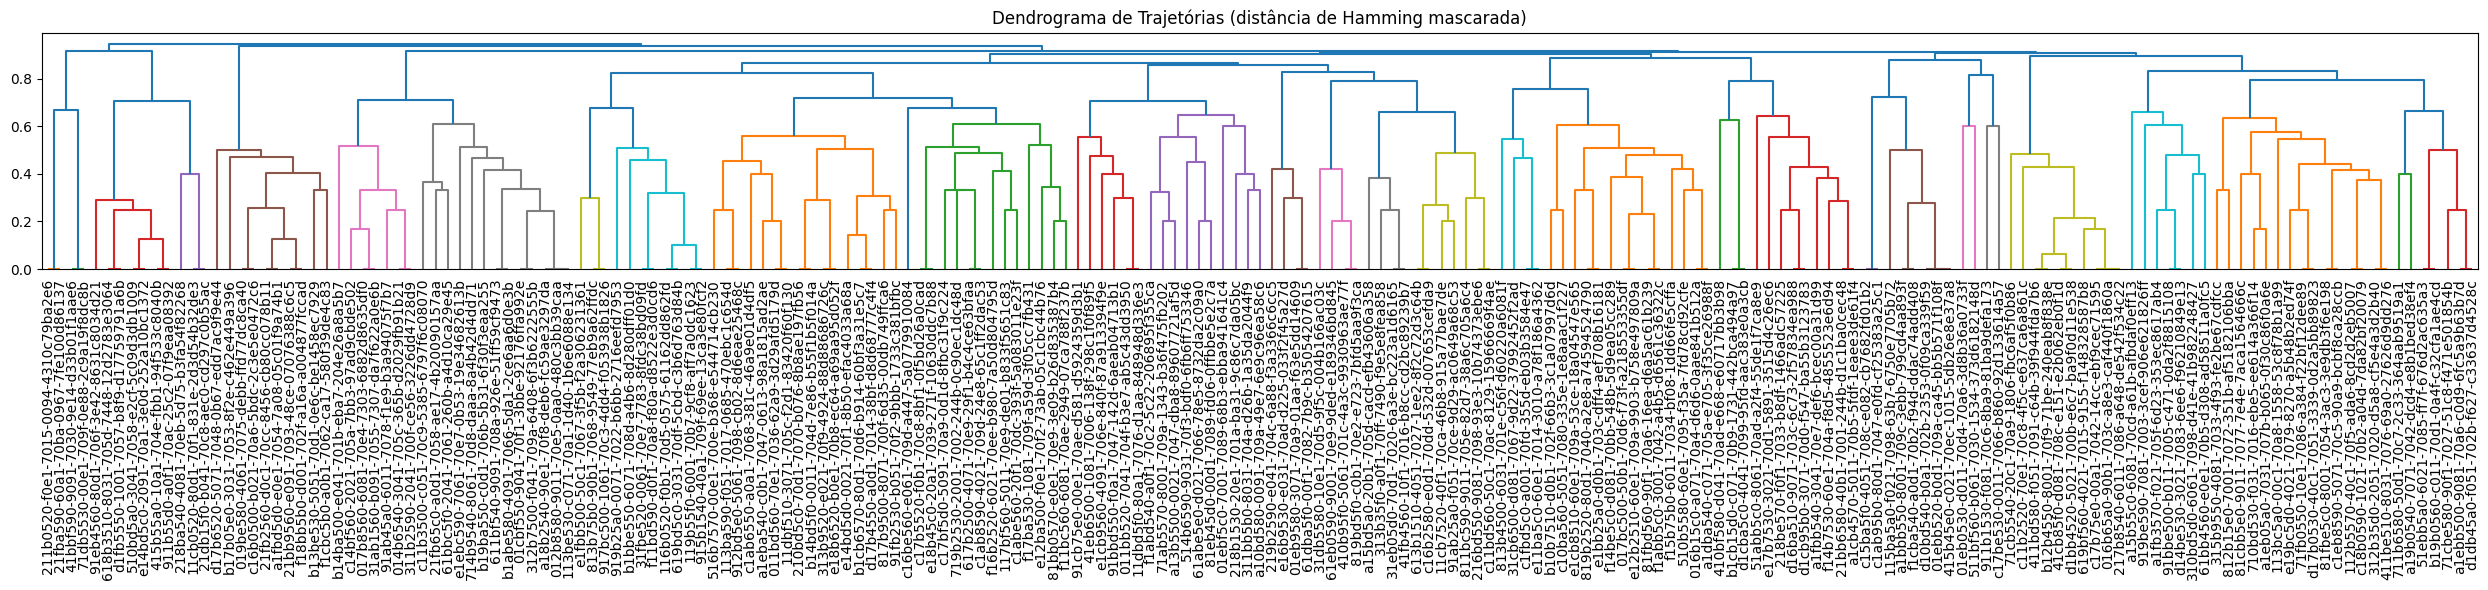

[Silhouette] best_k=27 com silhouette médio=0.2699


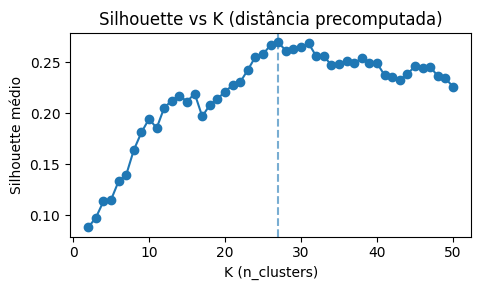

,trajectory_group
userId,
011bb520-7041-704f-b3e7-ab5c43dd3950,11
011bd560-70e1-7036-62a9-3d29afd5179d,10
012b8580-9011-70e5-0aa0-480c3bb39caa,12
014b6540-3041-705c-365b-d2029fb91b21,24
016b15c0-a071-70a4-d6d6-0aae841b512a,9


Grupos de trajetória salvos em: /Users/otacilio.maia/Desktop/studies/experimentosmestrado/helloworld/per_topic/trajetory/user_trajectory_groups.csv


/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38357/2196742420.py:117: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



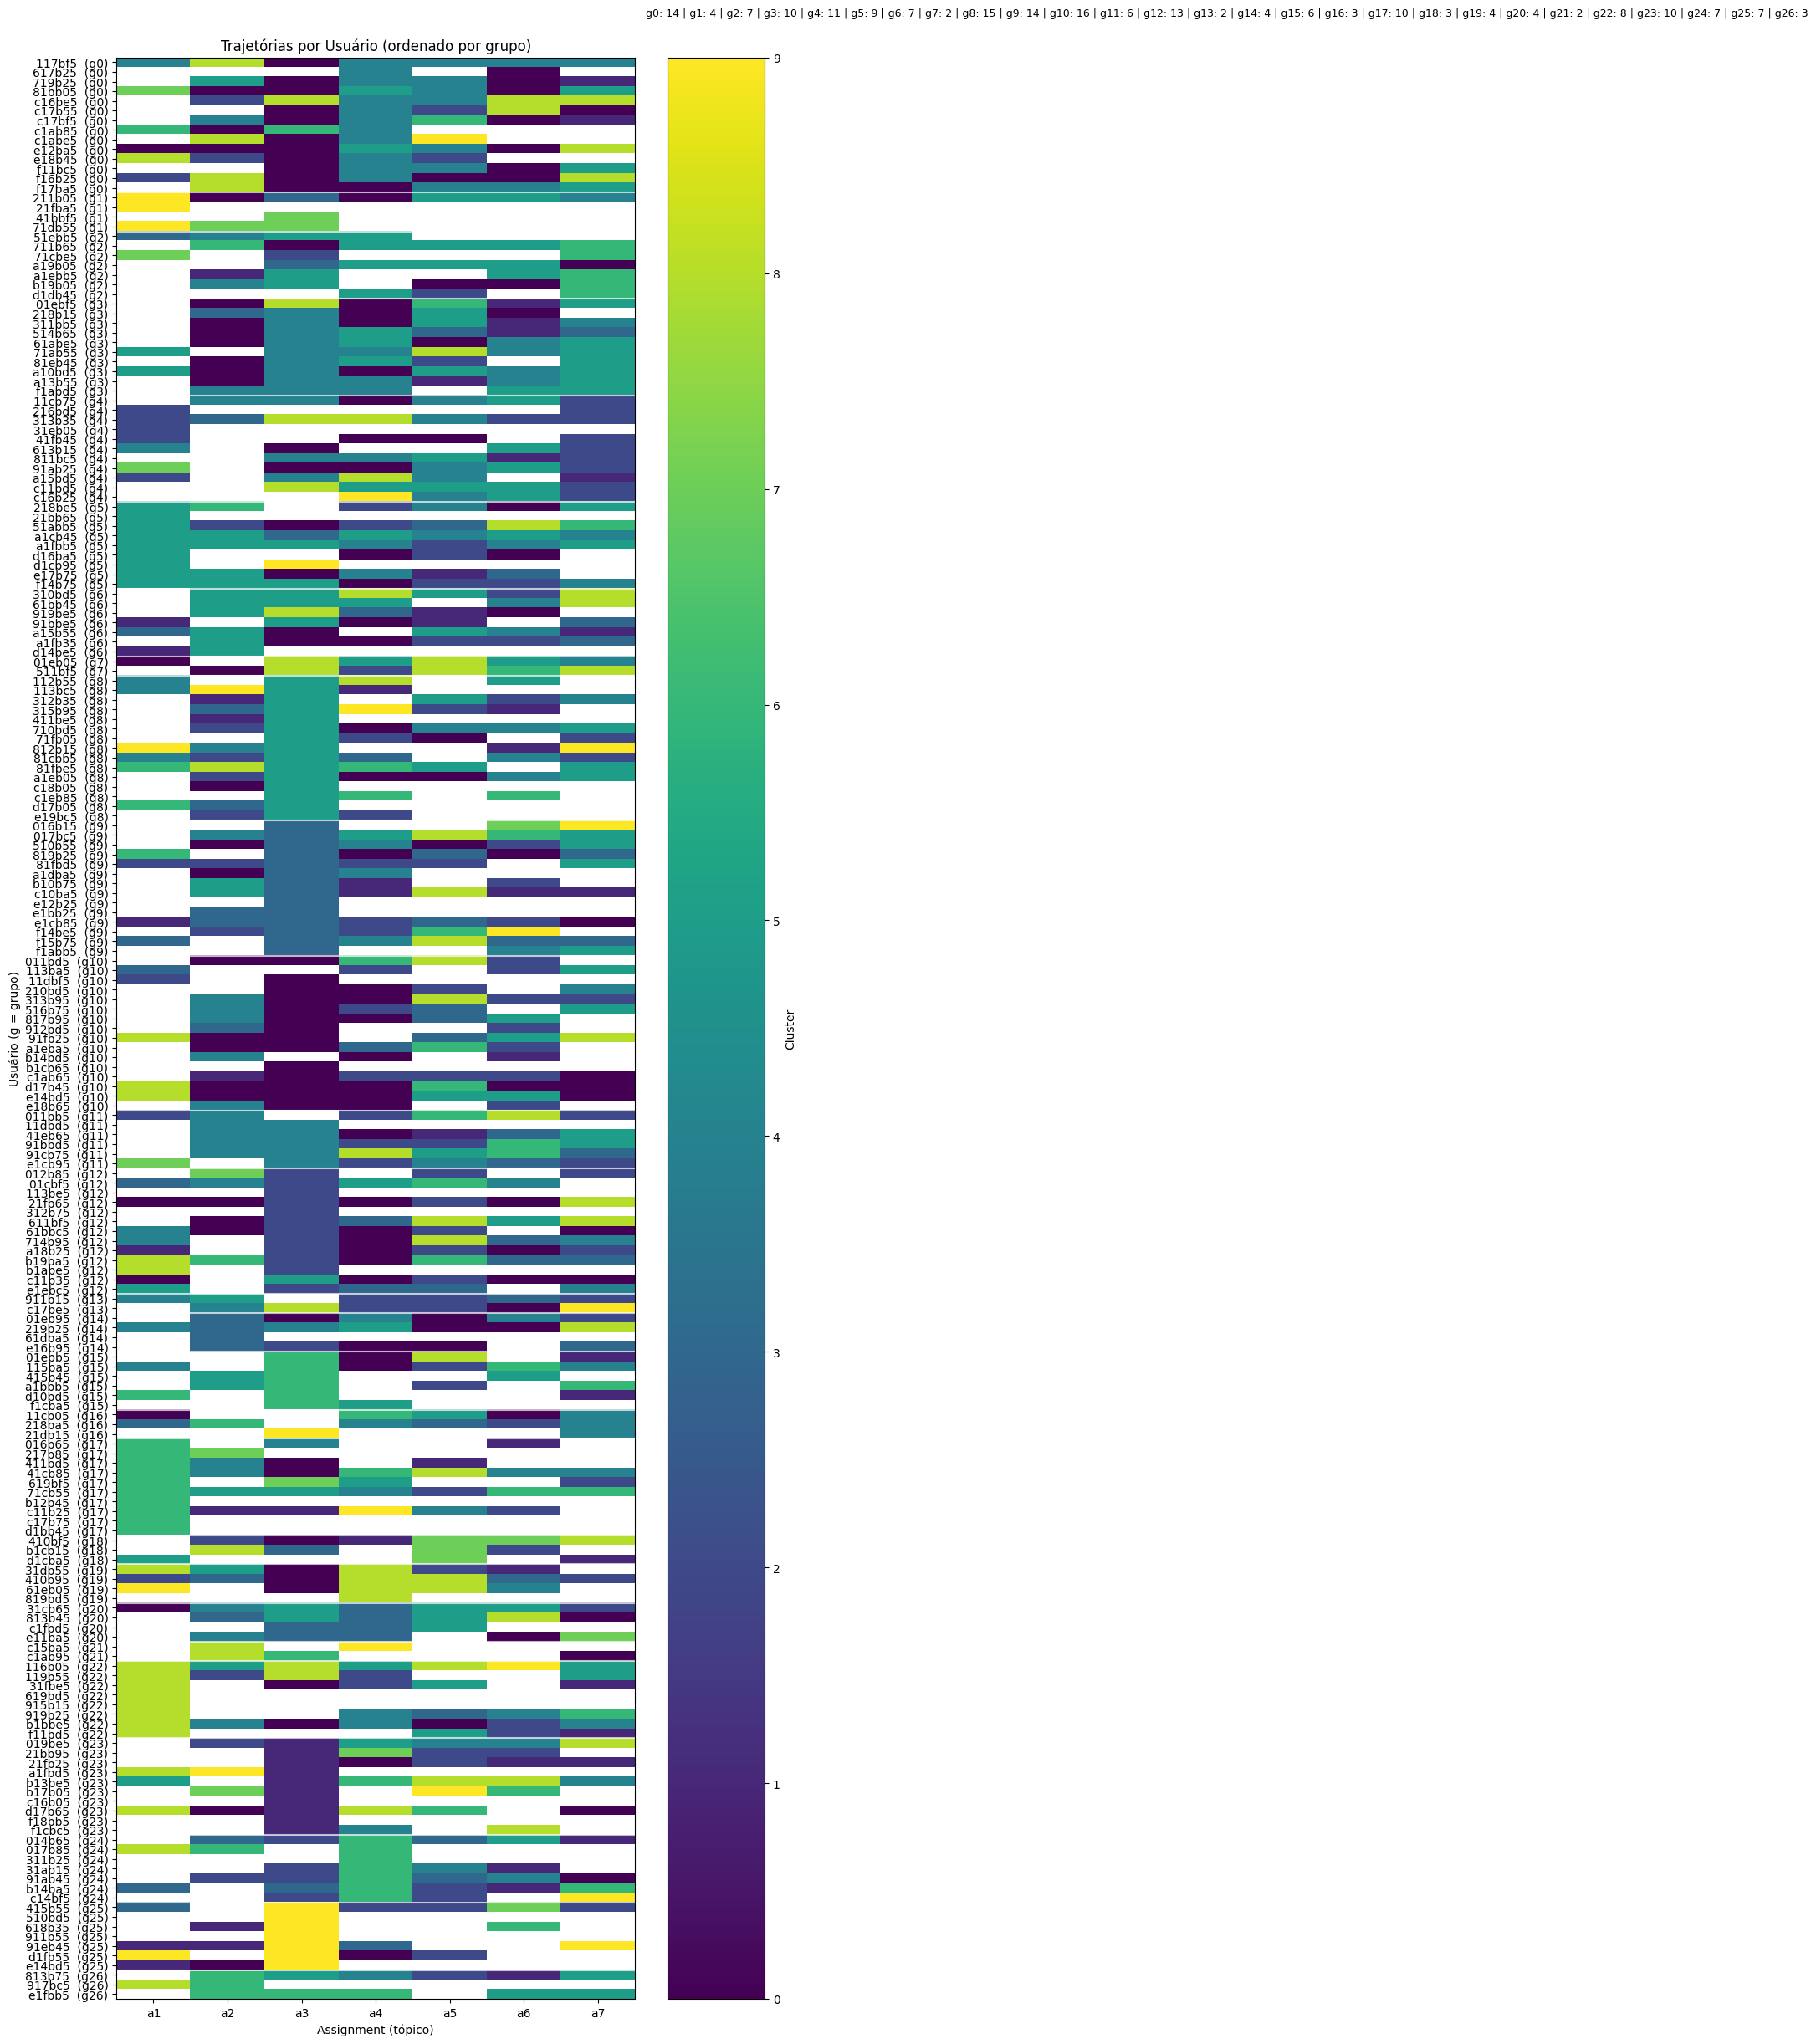

In [10]:
# =======================
# 6) Distância entre trajetórias (Hamming mascarado), seleção de K e clustering
# =======================
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import warnings
from collections import Counter
import numpy as np

def masked_hamming(u: np.ndarray, v: np.ndarray) -> float:
    mask = ~np.isnan(u) & ~np.isnan(v)
    if not np.any(mask):
        return 1.0
    return np.mean(u[mask] != v[mask])

X = traj.values.astype(float)
n = X.shape[0]

# 6.1) Matriz de distâncias
D = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(i+1, n):
        d = masked_hamming(X[i], X[j])
        D[i, j] = D[j, i] = d

# 6.2) Dendrograma
if n >= 2:
    D_cond = squareform(D, checks=False)
    Z = linkage(D_cond, method=LINKAGE)
    plt.figure(figsize=(25, 6))
    dendrogram(Z, labels=traj.index.tolist(), leaf_rotation=90, leaf_font_size=10)
    plt.title("Dendrograma de Trajetórias (distância de Hamming mascarada)")
    plt.tight_layout()
    plt.show()
else:
    Z = None
    print("Conjunto de usuários insuficiente para dendrograma.")

# 6.3) Seleção de K por Silhouette
K_MIN = 2
K_MAX = min(50, n)
best_k, best_sil = None, -1.0
sil_curve = []

if n >= 3:
    for k in range(K_MIN, max(K_MIN+1, K_MAX+1)):
        agg_linkage_eval = LINKAGE if LINKAGE != "ward" else "average"
        agg_eval = AgglomerativeClustering(
            n_clusters=min(k, n),
            linkage=agg_linkage_eval,
            metric="precomputed"
        )
        labels_k = agg_eval.fit_predict(D)
        if len(np.unique(labels_k)) < 2:
            sil_curve.append(np.nan); continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                sil = silhouette_score(D, labels_k, metric="precomputed")
            except Exception:
                sil = np.nan
        sil_curve.append(sil)
        if np.isfinite(sil) and sil > best_sil:
            best_sil, best_k = sil, k
    if best_k is None:
        best_k = max(2, min(4, n))
        print(f"[Silhouette] Fallback best_k={best_k}")
    else:
        print(f"[Silhouette] best_k={best_k} com silhouette médio={best_sil:.4f}")
    ks = list(range(K_MIN, max(K_MIN+1, K_MAX+1)))
    plt.figure(figsize=(5,3)); plt.plot(ks, sil_curve, marker='o'); plt.axvline(best_k, ls='--', alpha=0.6)
    plt.title("Silhouette vs K (distância precomputada)"); plt.xlabel("K (n_clusters)"); plt.ylabel("Silhouette médio")
    plt.tight_layout(); plt.show()
else:
    best_k = max(2, min(4, n)); print(f"[Silhouette] Poucos usuários; usando best_k={best_k}")

# 6.4) Clustering final
if n >= 2:
    agg_linkage = LINKAGE
    if agg_linkage == "ward":
        print("Aviso: 'ward' não é compatível com matriz precomputada. Usando 'average'.")
        agg_linkage = "average"
    try:
        agg = AgglomerativeClustering(n_clusters=min(best_k, n), linkage=agg_linkage, metric="precomputed")
    except TypeError:
        agg = AgglomerativeClustering(n_clusters=min(best_k, n), linkage=agg_linkage, affinity="precomputed")
    cluster_labels = agg.fit_predict(D)
else:
    cluster_labels = np.zeros(n, dtype=int)

# 6.5) Cluster DF e Heatmap
cluster_df = pd.DataFrame({"userId": traj.index, "trajectory_group": cluster_labels}).set_index("userId")
display(cluster_df.head())

groups_path = (OUT_DIR / "user_trajectory_groups.csv"); cluster_df.to_csv(groups_path)
print("Grupos de trajetória salvos em:", groups_path.resolve())

order = np.lexsort((traj.index.values, cluster_labels))
traj_sorted = traj.iloc[order]
sorted_user_ids = traj.index.values[order]
sorted_groups = cluster_labels[order]
yticklabels = [f"{str(uid)[:6]}  (g{g})" for uid, g in zip(sorted_user_ids, sorted_groups)]

fig, ax = plt.subplots(figsize=(10, max(4, len(traj_sorted)*0.15)))
im = ax.imshow(traj_sorted.values, aspect='auto', interpolation='nearest')
ax.set_xticks(range(len(TOPIC_ORDER))); ax.set_xticklabels(TOPIC_ORDER)
ax.set_yticks(range(len(traj_sorted.index))); ax.set_yticklabels(yticklabels)
boundaries = np.where(np.diff(sorted_groups) != 0)[0]
for b in boundaries: ax.axhline(b + 0.5, color='white', linewidth=1.5, alpha=0.7)
cbar = fig.colorbar(im, ax=ax); cbar.set_label('Cluster')
ax.set_title('Trajetórias por Usuário (ordenado por grupo)'); ax.set_xlabel('Assignment (tópico)'); ax.set_ylabel('Usuário (g = grupo)')
from collections import Counter as Cnt
counts = Cnt(sorted_groups); legend_txt = " | ".join([f"g{g}: {counts[g]}" for g in sorted(counts)])
ax.text(1.02, 1.02, legend_txt, transform=ax.transAxes, fontsize=9, va='bottom', ha='left')
plt.tight_layout(); plt.show()
